In [2]:
import pandas as pd
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('input/chemistry/lodders_m1/chem.dat', sep='\s+')

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/home/cwirth/ipykernel_3533685/1909988361.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv('input/chemistry/lodders_m1/chem.dat', sep='\s+')


In [4]:
df

,#P(bar),T(k),n_<tot>(cm-3),n_g(cm-3),m(u),e-,Al,Ar,C,Ca,...,S1+,S1-,Si1+,Si1-,Ti1+,Ti1-,V1+,V1-,Zn1+,Zn1-
0,0.000001,100.0,1.361325e+14,7.242963e+13,2.641834,3.757481e-193,3.968213e-154,0.000054,0.000000,2.620028e-149,...,0.000000e+00,5.996471e-241,0.000000e+00,0.000000e+00,2.058893e-302,0.000000e+00,3.475539e-283,1.299247e-311,8.415889e-280,1.340160e-196
1,0.000002,100.0,2.932887e+14,1.560449e+14,2.641834,1.439407e-193,2.703514e-154,0.000054,0.000000,1.216109e-149,...,0.000000e+00,2.297114e-241,0.000000e+00,0.000000e+00,2.494626e-302,0.000000e+00,4.211162e-283,1.072289e-311,1.019717e-279,1.106056e-196
2,0.000005,100.0,6.318712e+14,3.361886e+14,2.641834,5.514237e-194,1.841883e-154,0.000054,0.000000,5.644679e-150,...,0.000000e+00,8.800034e-242,0.000000e+00,0.000000e+00,3.022491e-302,0.000000e+00,5.102310e-283,8.850074e-312,1.235506e-279,9.128765e-197
3,0.000010,100.0,1.361325e+15,7.242963e+14,2.641834,2.112503e-194,1.254861e-154,0.000054,0.000000,2.620028e-150,...,0.000000e+00,3.371291e-242,0.000000e+00,0.000000e+00,3.661983e-302,0.000000e+00,6.181896e-283,7.304527e-312,1.496923e-279,7.534548e-197
4,0.000022,100.0,2.932887e+15,1.560449e+15,2.641834,8.093118e-195,8.549270e-155,0.000054,0.000000,1.216109e-150,...,0.000000e+00,1.291561e-242,0.000000e+00,0.000000e+00,4.436718e-302,0.000000e+00,7.489791e-283,6.028984e-312,1.813625e-279,6.218838e-197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3327,46.415890,6000.0,6.237179e+19,5.603143e+19,1.564648,1.442409e-04,1.983183e-05,0.000032,0.000185,4.583968e-06,...,3.277791e-08,1.602419e-08,6.664668e-06,9.653142e-09,4.088717e-07,1.378475e-12,3.457570e-08,2.733831e-13,3.588515e-09,2.153282e-12
3328,100.000000,6000.0,1.440228e+20,1.207161e+20,1.676974,1.078033e-04,2.336782e-05,0.000034,0.000114,6.873083e-06,...,1.933367e-08,2.450525e-08,3.999365e-06,1.501866e-08,3.277362e-07,2.864746e-12,2.645271e-08,5.422764e-13,2.395808e-09,3.727245e-12
3329,215.443500,6000.0,3.370924e+20,2.600749e+20,1.821841,7.949258e-05,2.626556e-05,0.000037,0.000078,9.710770e-06,...,1.096433e-08,3.507380e-08,2.366112e-06,2.242493e-08,2.532233e-07,5.586261e-12,1.985363e-08,1.027180e-12,1.641346e-09,6.444541e-12
3330,464.158900,6000.0,7.891052e+20,5.603143e+20,1.979535,5.692502e-05,2.792411e-05,0.000041,0.000060,1.251299e-05,...,5.943811e-09,4.525708e-08,1.405116e-06,3.169780e-08,1.913521e-07,1.004782e-11,1.481721e-08,1.824710e-12,1.157216e-09,1.081502e-11


/home/cwirth/ipykernel_3533685/2074385760.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


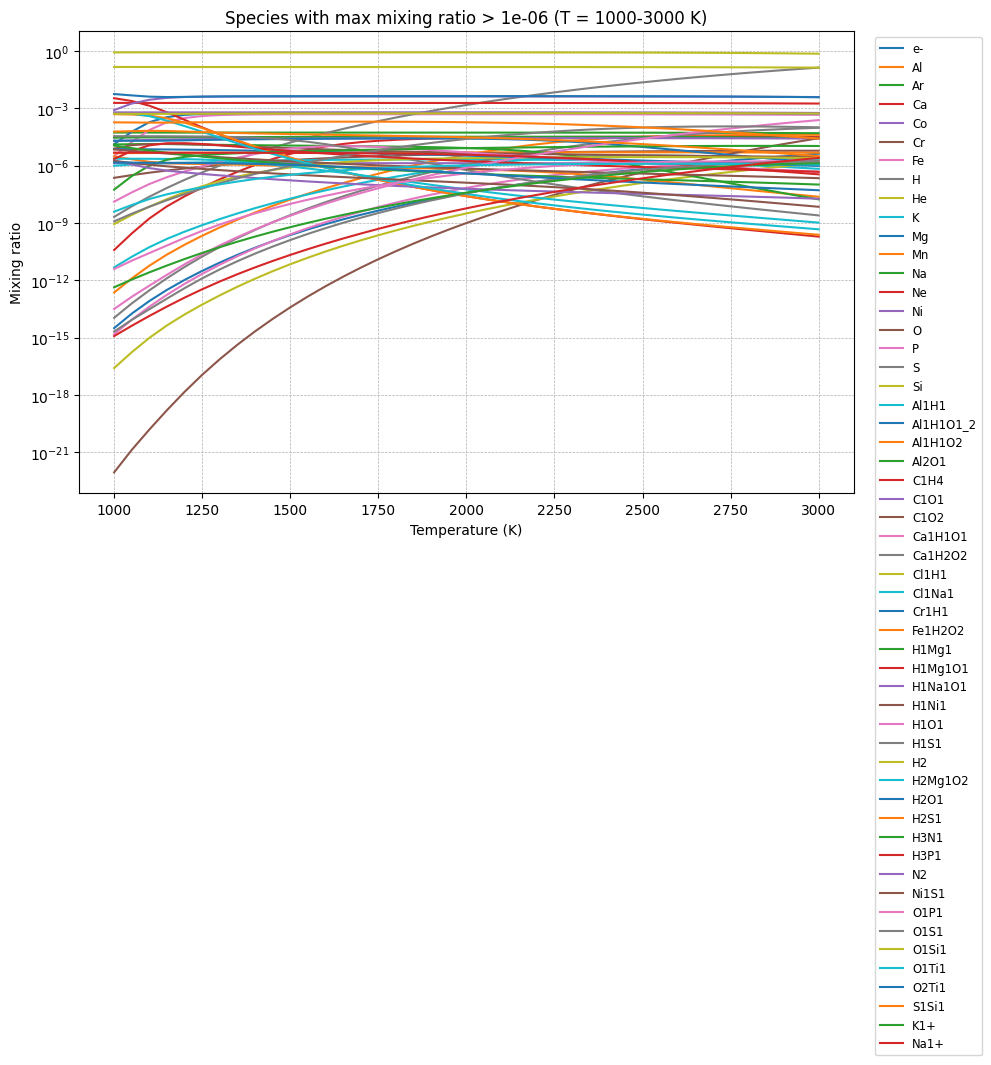

In [10]:
# select temperature column and sort rows by temperature
temp_col = 'T(k)'
df_sorted = df.sort_values(temp_col)
pressure_selected = 1e-0  # bar
df_sorted = df_sorted[df_sorted['#P(bar)'] == pressure_selected]

# restrict to temperature range 1000-3000 K
temp_min, temp_max = 1000, 3000
df_range = df_sorted[df_sorted[temp_col].between(temp_min, temp_max)]

# choose species whose maximum mixing ratio exceeds threshold (exclude columns with '(' like T(k))
threshold = 1e-6
species = [c for c in df.columns if '(' not in c and df_range[c].max() > threshold]

if df_range.empty:
    print(f"No rows found in temperature range {temp_min}-{temp_max} K.")
elif not species:
    print("No species found with max mixing ratio > 1e-6.")
else:
    x = df_range[temp_col]
    plt.figure(figsize=(10, 6))
    for col in species:
        plt.plot(x, df_range[col], label=col)
    plt.yscale('log')
    plt.xlabel('Temperature (K)')
    plt.ylabel('Mixing ratio')
    plt.title(f"Species with max mixing ratio > {threshold:.0e} (T = {temp_min}-{temp_max} K)")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(fontsize='small', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [11]:
# compute range slice (uses existing df_sorted, temp_col, temp_min, temp_max)
df_range = df_sorted[df_sorted[temp_col].between(temp_min, temp_max)]

if df_range.empty:
    print(f"No rows in temperature range {temp_min}-{temp_max} K.")
else:
    # ensure we only consider species whose max in the range exceeds the threshold
    cols = [c for c in species if df_range[c].max() > threshold]
    if not cols:
        print(f"No species with max mixing ratio > {threshold} in {temp_min}-{temp_max} K.")
    else:
        means = df_range[cols].mean()
        sorted_means = means.sort_values(ascending=False)
        # print ranked list with mean and max for context
        for i, col in enumerate(sorted_means.index, 1):
            mean_val = sorted_means.loc[col]
            max_val = df_range[col].max()
            print(f"{i:2d}. {col:20s} mean={mean_val:.3e}    max={max_val:.3e}")

 1. H2                   mean=8.241e-01    max=8.430e-01
 2. He                   mean=1.428e-01    max=1.454e-01
 3. H                    mean=2.011e-02    max=1.340e-01
 4. H2O1                 mean=4.265e-03    max=5.581e-03
 5. C1O1                 mean=3.913e-03    max=4.153e-03
 6. Ne                   mean=1.883e-03    max=1.916e-03
 7. N2                   mean=6.071e-04    max=6.134e-04
 8. O1Si1                mean=5.376e-04    max=5.540e-04
 9. Mg                   mean=5.228e-04    max=5.772e-04
10. Fe                   mean=4.338e-04    max=4.880e-04
11. C1H4                 mean=2.001e-04    max=3.377e-03
12. H2S1                 mean=1.467e-04    max=2.001e-04
13. Ar                   mean=5.307e-05    max=5.401e-05
14. Fe1H2O2              mean=4.974e-05    max=4.895e-04
15. H2Mg1O2              mean=4.770e-05    max=5.768e-04
16. H1S1                 mean=4.485e-05    max=1.131e-04
17. Na                   mean=3.145e-05    max=3.267e-05
18. S1Si1                mean=3

In [2]:
from dace_query.opacity import Atom, Molecule

2025-11-18 13:08:49,332 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch


In [ ]:
Atom.download(line_list='NIST', version=1.0, temperature_boundaries=(0, 6000), pressure_boundaries=(-8, 3), output_directory='./opacity')

2025-11-18 11:39:06,574 - INFO - Downloading file on location : opacity/P_0_NIST.tar.gz


 Download : 426 MB

2025-11-18 11:40:55,402 - INFO - File downloaded on location : opacity/P_0_NIST.tar.gz



Download done


In [8]:
Molecule.download('32S-16O', line_list='SOLIS', version=1.0, temperature_boundaries=(0, 6000), pressure_boundaries=(-8, 3), output_directory='./opacity')

2025-11-18 14:35:45,101 - INFO - Downloading file on location : opacity/32S-16O_SOLIS.tar.gz


 Download : 20109 MB

2025-11-18 15:18:40,444 - INFO - File downloaded on location : opacity/32S-16O_SOLIS.tar.gz



Download done
